# ATT&CK Campaign Motivation Exploration

**Author:** Marc Labouchardiere (23857377) · **Supervisor:** Dr Jin B. Hong
**Date:** 2026-04-16 · **Thesis context:** MTDShield — adaptive MTD for dynamic networks.

## Why this notebook exists

Sub-problem 1 of the thesis requires generalised adversary profiles that differ by **motivation** (espionage vs financial vs destructive etc.), because motivation shapes TTP selection, persistence, and stealth requirements. MITRE ATT&CK is our TTP source — but ATT&CK Campaign and Intrusion-Set (Group) objects **do not populate** the STIX `primary_motivation` / `secondary_motivations` fields. Motivation exists only in free-text `description` prose.

This notebook:
1. **Proves the gap** programmatically (Part 1).
2. **Explores three motivation-attribution strategies**: description keyword extraction (Part 2), group-mediated inference via `attributed-to` relationships (Part 3), and unsupervised TTP clustering to test whether motivation-driven behaviour is discoverable from techniques alone (Part 4).
3. **Produces tactic-distribution profiles** (Part 5) usable as MTDShield adversary archetypes.

## Scope decisions

- **Self-contained**: no imports from `src/mtdsim/...`. Existing `enrich_group_profiles` / `extract_campaigns` helpers are deliberately not reused — exploratory analysis must be independent of prior implementation to avoid biasing findings.
- **Taxonomy**: STIX `attack-motivation-ov` (9 categories). Sparse at n≈30 but matches the spec; collapse only if data demands.
- **Staged delivery**: Part 1 runs in this first pass. Parts 2–6 are stubs to be filled in once Part 1 outputs inform the design (e.g. description length distribution shapes the keyword approach).

## Caveats up front

- n ≈ 25–35 campaigns → any clustering is noisy; exploratory, not statistical proof.
- CTI observation bias: multiple techniques per campaign often trace to a single vendor report.
- Ground truth must come from **external** CTI sources (not the ATT&CK descriptions themselves) to avoid circular validation.


---
## Part 1 — Schema audit: proving the gap

**Objective**: demonstrate programmatically that motivation is absent as structured data from ATT&CK Campaign and Group objects.


In [2]:
# Cell 1 — Environment setup
from __future__ import annotations

import json
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mitreattack.stix20 import MitreAttackData

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)


In [3]:
# Cell 2 — Load the ATT&CK Enterprise STIX bundle
BUNDLE_PATH = Path("enterprise-attack.json")
BUNDLE_URL = "https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/enterprise-attack/enterprise-attack.json"

if not BUNDLE_PATH.exists():
    import urllib.request
    print(f"Downloading bundle to {BUNDLE_PATH} ...")
    urllib.request.urlretrieve(BUNDLE_URL, BUNDLE_PATH)

with BUNDLE_PATH.open() as f:
    raw_bundle = json.load(f)

# Find spec version from any object that advertises it
spec_versions = {obj.get("x_mitre_attack_spec_version") for obj in raw_bundle.get("objects", [])} - {None}
bundle_mtime = datetime.fromtimestamp(BUNDLE_PATH.stat().st_mtime).isoformat(timespec="seconds")

mitre = MitreAttackData(str(BUNDLE_PATH))

campaigns = mitre.get_campaigns()
groups = mitre.get_groups()

print(f"Bundle path:     {BUNDLE_PATH.resolve()}")
print(f"Bundle mtime:    {bundle_mtime}")
print(f"Spec version(s): {sorted(spec_versions)}")
print(f"Campaigns:       {len(campaigns)}")
print(f"Groups:          {len(groups)}")


Bundle path:     /home/marc/GitHub/MTDSim/notebooks/enterprise-attack.json
Bundle mtime:    2026-03-30T10:39:38
Spec version(s): ['3.2.0', '3.3.0']
Campaigns:       52
Groups:          187


In [4]:
# Cell 3 — Campaign object audit: which STIX fields are actually populated?
MOTIVATION_FIELDS = ["primary_motivation", "secondary_motivations", "goals", "objective"]

def object_field_row(obj, name_attr="name"):
    props = {k: v for k, v in obj.items()} if hasattr(obj, "items") else dict(obj)
    desc = props.get("description", "") or ""
    row = {
        "stix_id": props.get("id"),
        "name": props.get(name_attr, ""),
        "n_keys": len(props),
        "desc_len": len(desc),
    }
    for field in MOTIVATION_FIELDS:
        row[f"has_{field}"] = field in props and bool(props.get(field))
    return row, sorted(props.keys())

campaign_rows = []
all_campaign_keys = set()
for c in campaigns:
    row, keys = object_field_row(c)
    campaign_rows.append(row)
    all_campaign_keys.update(keys)

campaign_df = pd.DataFrame(campaign_rows).sort_values("name").reset_index(drop=True)

print("Union of all keys observed across campaign objects:")
for k in sorted(all_campaign_keys):
    print(f"  - {k}")

print("\nMotivation-field population across campaigns:")
for field in MOTIVATION_FIELDS:
    col = f"has_{field}"
    print(f"  {field:25s}  populated in {campaign_df[col].sum():>3d} / {len(campaign_df)} campaigns")

campaign_df


Union of all keys observed across campaign objects:
  - aliases
  - created
  - created_by_ref
  - description
  - external_references
  - first_seen
  - id
  - last_seen
  - modified
  - name
  - object_marking_refs
  - revoked
  - type
  - x_mitre_attack_spec_version
  - x_mitre_contributors
  - x_mitre_deprecated
  - x_mitre_domains
  - x_mitre_first_seen_citation
  - x_mitre_last_seen_citation
  - x_mitre_modified_by_ref
  - x_mitre_version

Motivation-field population across campaigns:
  primary_motivation         populated in   0 / 52 campaigns
  secondary_motivations      populated in   0 / 52 campaigns
  goals                      populated in   0 / 52 campaigns
  objective                  populated in   0 / 52 campaigns


,stix_id,name,n_keys,desc_len,has_primary_motivation,has_secondary_motivations,has_goals,has_objective
0,campaign--46421788-b6e1-4256-b351-f8beffd1afba,2015 Ukraine Electric Power Attack,20,516,False,False,False,False
1,campaign--aa73efef-1418-4dbe-b43c-87a498e97234,2016 Ukraine Electric Power Attack,20,513,False,False,False,False
2,campaign--df8eb785-70f8-4300-b444-277ba849083d,2022 Ukraine Electric Power Attack,20,483,False,False,False,False
3,campaign--4fd53ccc-c6b1-4e3c-abe8-a456d46d789e,3CX Supply Chain Attack,21,1216,False,False,False,False
4,campaign--a010610e-22cb-437e-bfde-b78861bdca7a,APT28 Nearest Neighbor Campaign,20,786,False,False,False,False
5,campaign--add4d9de-1256-4166-83b8-57087288dced,APT41 DUST,20,668,False,False,False,False
6,campaign--a543ef15-91ea-4aa9-9c10-267d56e1ee82,ArcaneDoor,21,691,False,False,False,False
7,campaign--ab747e62-1bcb-479f-a26b-1cd39d413d81,C0010,20,544,False,False,False,False
8,campaign--b4e5a4a9-f3be-4631-ba8f-da6ebb067fac,C0011,20,568,False,False,False,False
9,campaign--78068e68-4124-4243-b6f4-76e4e5be8a06,C0015,21,572,False,False,False,False


In [5]:
# Cell 3b — Print one full campaign object to make the absence concrete
sample = dict(campaigns[0])
print(f"Sample campaign: {sample.get('name')} ({sample.get('id')})")
print("-" * 72)
for k, v in sample.items():
    if k == "description":
        snippet = (v or "")[:240].replace("\n", " ")
        print(f"  {k}: {snippet}{'...' if len(v or '') > 240 else ''}")
    else:
        print(f"  {k}: {v!r}")


Sample campaign: C0027 (campaign--df74f7ad-b10d-431c-9f1d-a2bc18dadefa)
------------------------------------------------------------------------
  type: 'campaign'
  id: 'campaign--df74f7ad-b10d-431c-9f1d-a2bc18dadefa'
  created_by_ref: 'identity--c78cb6e5-0c4b-4611-8297-d1b8b55e40b5'
  created: '2023-06-30T19:28:30.616Z'
  modified: '2025-04-16T20:37:45.650Z'
  name: 'C0027'
  description: [C0027](https://attack.mitre.org/campaigns/C0027) was a financially-motivated campaign linked to [Scattered Spider](https://attack.mitre.org/groups/G1015) that targeted telecommunications and business process outsourcing (BPO) companies fro...
  aliases: ['C0027']
  first_seen: '2022-06-01T04:00:00Z'
  last_seen: '2022-12-01T05:00:00Z'
  revoked: False
  external_references: [ExternalReference(source_name='mitre-attack', url='https://attack.mitre.org/campaigns/C0027', external_id='C0027'), ExternalReference(source_name='Crowdstrike TELCO BPO Campaign December 2022', description='Parisi, T. (2022, De

In [6]:
# Cell 4 — Group (Intrusion-Set) object audit
group_rows = []
all_group_keys = set()
for g in groups:
    row, keys = object_field_row(g)
    group_rows.append(row)
    all_group_keys.update(keys)

group_df = pd.DataFrame(group_rows).sort_values("name").reset_index(drop=True)

print("Union of all keys observed across group (intrusion-set) objects:")
for k in sorted(all_group_keys):
    print(f"  - {k}")

print("\nMotivation-field population across groups:")
for field in MOTIVATION_FIELDS:
    col = f"has_{field}"
    n = group_df[col].sum()
    print(f"  {field:25s}  populated in {n:>3d} / {len(group_df)} groups")

# Any single positive case invalidates Parts 2–4's premise and must be flagged.
any_populated = group_df[[f"has_{f}" for f in MOTIVATION_FIELDS]].any().any()
if any_populated:
    print("\n!!  Premise check: at least one group carries a STIX motivation field — inspect before proceeding.")
else:
    print("\nPremise confirmed: no group in the bundle carries STIX motivation fields as structured data.")

group_df.head(10)


Union of all keys observed across group (intrusion-set) objects:
  - aliases
  - created
  - created_by_ref
  - description
  - external_references
  - id
  - modified
  - name
  - object_marking_refs
  - revoked
  - type
  - x_mitre_attack_spec_version
  - x_mitre_contributors
  - x_mitre_deprecated
  - x_mitre_domains
  - x_mitre_modified_by_ref
  - x_mitre_version

Motivation-field population across groups:
  primary_motivation         populated in   0 / 187 groups
  secondary_motivations      populated in   0 / 187 groups
  goals                      populated in   0 / 187 groups
  objective                  populated in   0 / 187 groups

Premise confirmed: no group in the bundle carries STIX motivation fields as structured data.


,stix_id,name,n_keys,desc_len,has_primary_motivation,has_secondary_motivations,has_goals,has_objective
0,intrusion-set--8332952e-b86b-486b-acc3-1c2a85d39394,APT-C-23,17,438,False,False,False,False
1,intrusion-set--c4d50cdf-87ce-407d-86d8-862883485842,APT-C-36,17,342,False,False,False,False
2,intrusion-set--6a2e693f-24e5-451a-9f88-b36a108e5662,APT1,16,302,False,False,False,False
3,intrusion-set--c47f937f-1022-4f42-8525-e7a4779a14cb,APT12,16,267,False,False,False,False
4,intrusion-set--d6e88e18-81e8-4709-82d8-973095da1e70,APT16,16,205,False,False,False,False
5,intrusion-set--090242d7-73fc-4738-af68-20162f7a5aae,APT17,16,293,False,False,False,False
6,intrusion-set--38fd6a28-3353-4f2b-bb2b-459fecd5c648,APT18,16,259,False,False,False,False
7,intrusion-set--fe8796a4-2a02-41a0-9d27-7aa1e995feb6,APT19,17,685,False,False,False,False
8,intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e85917c,APT28,17,1687,False,False,False,False
9,intrusion-set--899ce53f-13a0-479b-a0e4-67d46e241542,APT29,17,1438,False,False,False,False


Description length summary:
  Campaigns: {'count': 52.0, 'mean': 721.0, 'std': 300.0, 'min': 291.0, '25%': 540.0, '50%': 647.0, '75%': 816.0, 'max': 2160.0}
  Groups:    {'count': 187.0, 'mean': 583.0, 'std': 327.0, 'min': 0.0, '25%': 346.0, '50%': 527.0, '75%': 730.0, 'max': 1872.0}


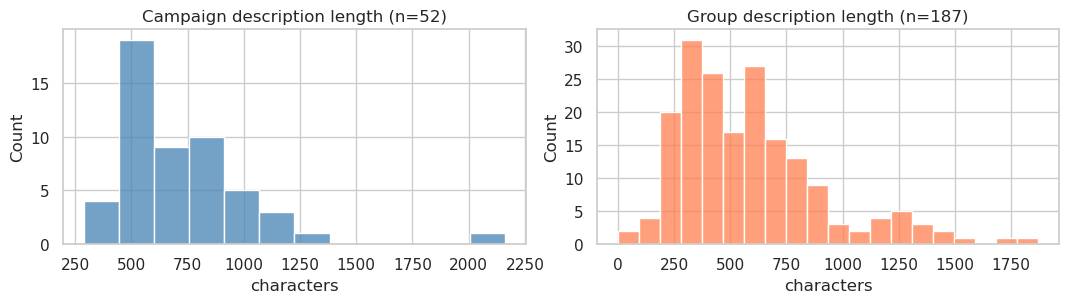

,object_type,stix_supports_motivation,attck_populates_it,where_motivation_lives
0,Campaign,objective (string),No,free-text `description`
1,Intrusion Set (Group),"primary_motivation, secondary_motivations, goals",No,free-text `description`
2,Threat Actor,"primary_motivation, secondary_motivations",ATT&CK does not use Threat Actor objects,n/a


In [7]:
# Cell 5 — Gap summary and description-length distribution
gap_summary = pd.DataFrame([
    {
        "object_type": "Campaign",
        "stix_supports_motivation": "objective (string)",
        "attck_populates_it": "No",
        "where_motivation_lives": "free-text `description`",
    },
    {
        "object_type": "Intrusion Set (Group)",
        "stix_supports_motivation": "primary_motivation, secondary_motivations, goals",
        "attck_populates_it": "No",
        "where_motivation_lives": "free-text `description`",
    },
    {
        "object_type": "Threat Actor",
        "stix_supports_motivation": "primary_motivation, secondary_motivations",
        "attck_populates_it": "ATT&CK does not use Threat Actor objects",
        "where_motivation_lives": "n/a",
    },
])

print("Description length summary:")
print("  Campaigns:", campaign_df["desc_len"].describe().round(0).to_dict())
print("  Groups:   ", group_df["desc_len"].describe().round(0).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
sns.histplot(campaign_df["desc_len"], bins=12, color="steelblue", ax=axes[0])
axes[0].set_title(f"Campaign description length (n={len(campaign_df)})")
axes[0].set_xlabel("characters")
sns.histplot(group_df["desc_len"], bins=20, color="coral", ax=axes[1])
axes[1].set_title(f"Group description length (n={len(group_df)})")
axes[1].set_xlabel("characters")
plt.tight_layout()
plt.show()

gap_summary


### Part 1 findings (to be filled in after running)

After executing Cells 1–5, record here:
- ATT&CK spec version and bundle date
- Campaign count (expect 25–35 for v16+)
- Group count (expect ~140 for v16+)
- Confirmation that no STIX motivation fields are populated
- Campaign description length distribution — this is the decisive input for Part 2's keyword approach viability
- Group description length distribution — compare against campaign; Part 3 should benefit from richer group text

**Decision point**: if median campaign description length is < 300 chars, keyword extraction (Part 2) will likely perform poorly and we should consider swapping it for an LLM-based extraction or demoting Part 2 to a pure baseline.


---
## Part 2 — Description-based motivation extraction

**Objective**: extract motivation labels from campaign and group descriptions using keyword/regex heuristics, compare against an externally-sourced ground truth.

**Taxonomy**: STIX `attack-motivation-ov` (10 categories). In practice, ATT&CK campaigns concentrate in 3–4 categories — the sparsity itself is a finding.

**Design decisions** (informed by Part 1):
- Median campaign description is 647 chars — enough for keyword matching.
- Word-boundary regex (`\b`) to avoid substring false positives.
- Abstain threshold: ≥ 2 keyword hits for a label; otherwise `unknown`.
- Combined decision rule: when campaign-text and group-text disagree, prefer group-text (longer, more CTI-grounded) but flag conflict.

In [25]:
# Cell 6 — STIX attack-motivation-ov taxonomy with keyword regexes
#
# Maps each STIX motivation category to regex patterns (word-boundary-delimited).
# "reconnaissance" is deliberately excluded from organizational-gain — it's universal.

MOTIVATION_KEYWORDS: dict[str, list[str]] = {
    "organizational-gain": [
        r"\bespionage\b", r"\bintelligence\s+gathering\b", r"\bstate[\-\s]sponsored\b",
        r"\bnation[\-\s]state\b", r"\bgovernment[\-\s]backed\b", r"\bsurveillance\b",
        r"\bexfiltrat\w*\b", r"\bintellectual\s+property\b", r"\bcyber\s+espionage\b",
        r"\bspy\b", r"\bspying\b", r"\bcollection\s+campaign\b",
    ],
    "personal-financial-gain": [
        r"\bfinancial\w*\b", r"\bransom\w*\b", r"\bmonetary\b", r"\bbanking\b",
        r"\bcryptocurrenc\w*\b", r"\bfraud\w*\b", r"\bextortion\b", r"\bprofit\w*\b",
        r"\bcarding\b", r"\btheft\s+of\s+funds\b", r"\bhacker[\-\s]for[\-\s]hire\b",
    ],
    "dominance": [
        r"\bdisrupt\w*\b", r"\bwiper\b", r"\bsabotag\w*\b", r"\bdestruct\w*\b",
        r"\bcoercive\b", r"\bpower\s+grid\b", r"\belectric\s+power\b",
        r"\bsafety\s+instrumented\b", r"\bICS\b",
    ],
    "ideology": [
        r"\bhacktivis\w*\b", r"\bactivist\w*\b", r"\bideolog\w*\b",
        r"\bpolitical\s+statement\b", r"\bprotest\w*\b",
    ],
    "coercion": [
        r"\bcoerci\w*\b", r"\bintimidat\w*\b", r"\bblackmail\b", r"\bthreat\s+of\s+harm\b",
    ],
    "notoriety": [
        r"\bnotoriety\b", r"\bfame\b", r"\bpublic\s+attention\b", r"\bbragging\b",
    ],
    "personal-satisfaction": [
        r"\bpersonal\s+satisfaction\b", r"\bcuriosity\b", r"\bfor\s+fun\b",
    ],
    "revenge": [
        r"\brevenge\b", r"\bretaliat\w*\b", r"\bgrievance\b",
    ],
    "unpredictable": [],
    "accidental": [],
}

MOTIVATION_COLOURS = {
    "organizational-gain": "#2c7bb6",
    "personal-financial-gain": "#d7191c",
    "dominance": "#fdae61",
    "ideology": "#abd9e9",
    "coercion": "#b35806",
    "notoriety": "#7b3294",
    "personal-satisfaction": "#c2a5cf",
    "revenge": "#e66101",
    "unpredictable": "#999999",
    "accidental": "#cccccc",
    "unknown": "#f0f0f0",
}

print(f"Taxonomy: {len(MOTIVATION_KEYWORDS)} STIX categories")
for cat, patterns in MOTIVATION_KEYWORDS.items():
    print(f"  {cat:30s}  {len(patterns):2d} patterns")

Taxonomy: 10 STIX categories
  organizational-gain             12 patterns
  personal-financial-gain         11 patterns
  dominance                        9 patterns
  ideology                         5 patterns
  coercion                         4 patterns
  notoriety                        4 patterns
  personal-satisfaction            3 patterns
  revenge                          3 patterns
  unpredictable                    0 patterns
  accidental                       0 patterns


In [26]:
# Cell 7 — Apply keyword extraction to campaign descriptions

def extract_motivation(text: str, threshold: int = 2) -> dict:
    """Score text against each motivation category. Return best label if >= threshold hits."""
    text_lower = (text or "").lower()
    scores = {}
    hits_detail = {}
    for cat, patterns in MOTIVATION_KEYWORDS.items():
        matches = []
        for p in patterns:
            found = re.findall(p, text_lower)
            matches.extend(found)
        scores[cat] = len(matches)
        if matches:
            hits_detail[cat] = matches
    best_cat = max(scores, key=scores.get)
    best_score = scores[best_cat]
    label = best_cat if best_score >= threshold else "unknown"
    return {"label": label, "confidence": best_score, "scores": scores, "hits": hits_detail}

def campaign_id_from_refs(ext_refs) -> str:
    for r in (ext_refs or []):
        src = r.get("source_name", "") if isinstance(r, dict) else getattr(r, "source_name", "")
        if src == "mitre-attack":
            return r.get("external_id", "") if isinstance(r, dict) else getattr(r, "external_id", "")
    return ""

campaign_extraction_rows = []
for c in campaigns:
    props = dict(c) if not isinstance(c, dict) else c
    desc = props.get("description", "") or ""
    ext_refs = props.get("external_references", [])
    cid = campaign_id_from_refs(ext_refs)
    result = extract_motivation(desc)
    campaign_extraction_rows.append({
        "campaign_id": cid,
        "campaign_name": props.get("name", ""),
        "stix_id": props.get("id", ""),
        "desc_len": len(desc),
        "desc_snippet": desc[:150].replace("\n", " "),
        "kw_motivation": result["label"],
        "kw_confidence": result["confidence"],
        "kw_hits": str(result["hits"]) if result["hits"] else "",
    })

campaign_kw_df = pd.DataFrame(campaign_extraction_rows).sort_values("campaign_id").reset_index(drop=True)

print("Keyword extraction results (campaign descriptions):")
print(campaign_kw_df["kw_motivation"].value_counts().to_string())
print(f"\nTotal: {len(campaign_kw_df)} campaigns, {(campaign_kw_df['kw_motivation'] == 'unknown').sum()} labelled 'unknown'")
campaign_kw_df[["campaign_id", "campaign_name", "kw_motivation", "kw_confidence", "kw_hits"]].head(20)

Keyword extraction results (campaign descriptions):
kw_motivation
unknown                    36
organizational-gain        10
personal-financial-gain     3
dominance                   3

Total: 52 campaigns, 36 labelled 'unknown'


,campaign_id,campaign_name,kw_motivation,kw_confidence,kw_hits
0,C0001,Frankenstein,unknown,0,
1,C0002,Night Dragon,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage'], 'personal-financial-gain': ['financials']}"
2,C0004,CostaRicto,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage'], 'personal-financial-gain': ['financial', 'hacker-for-hire']}"
3,C0005,Operation Spalax,unknown,1,{'personal-financial-gain': ['banking']}
4,C0006,Operation Honeybee,unknown,0,
5,C0007,FunnyDream,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage']}"
6,C0010,C0010,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage']}"
7,C0011,C0011,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage']}"
8,C0012,Operation CuckooBees,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage']}"
9,C0013,Operation Sharpshooter,organizational-gain,2,"{'organizational-gain': ['espionage', 'cyber espionage'], 'personal-financial-gain': ['financial']}"


In [27]:
# Cell 8 — Apply keyword extraction to attributed-to group descriptions
#
# For each campaign, traverse the attributed-to relationship to find parent group(s),
# then run keyword extraction on the group's (typically richer) description.

def get_campaign_group_map(mitre_data, campaign_list):
    """Build {campaign_stix_id: [list of {group_stix_id, group_name, group_desc}]}."""
    mapping = {}
    for c in campaign_list:
        c_id = c["id"] if isinstance(c, dict) else c.id
        try:
            attributed_groups = mitre_data.get_groups_attributing_to_campaign(c_id)
        except Exception:
            attributed_groups = []
        group_info = []
        for g in (attributed_groups or []):
            gprops = dict(g) if not isinstance(g, dict) else g
            group_info.append({
                "group_stix_id": gprops.get("id", ""),
                "group_name": gprops.get("name", ""),
                "group_desc": gprops.get("description", "") or "",
            })
        mapping[c_id] = group_info
    return mapping

campaign_group_map = get_campaign_group_map(mitre, campaigns)

group_extraction_rows = []
for c in campaigns:
    props = dict(c) if not isinstance(c, dict) else c
    c_stix = props.get("id", "")
    cid = campaign_id_from_refs(props.get("external_references", []))
    cname = props.get("name", "")
    parent_groups = campaign_group_map.get(c_stix, [])
    if not parent_groups:
        group_extraction_rows.append({
            "campaign_id": cid, "campaign_name": cname,
            "group_name": "(none)", "group_kw_motivation": "unknown",
            "group_kw_confidence": 0, "group_kw_hits": "",
        })
    else:
        for g in parent_groups:
            result = extract_motivation(g["group_desc"])
            group_extraction_rows.append({
                "campaign_id": cid, "campaign_name": cname,
                "group_name": g["group_name"],
                "group_kw_motivation": result["label"],
                "group_kw_confidence": result["confidence"],
                "group_kw_hits": str(result["hits"]) if result["hits"] else "",
            })

group_kw_df = pd.DataFrame(group_extraction_rows).sort_values("campaign_id").reset_index(drop=True)

n_no_group = (group_kw_df["group_name"] == "(none)").sum()
print(f"Group-description keyword extraction: {len(group_kw_df)} rows ({n_no_group} campaigns with no attributed group)")
print(group_kw_df["group_kw_motivation"].value_counts().to_string())
group_kw_df[["campaign_id", "campaign_name", "group_name", "group_kw_motivation", "group_kw_confidence"]].head(20)

Group-description keyword extraction: 53 rows (28 campaigns with no attributed group)
group_kw_motivation
unknown    53


,campaign_id,campaign_name,group_name,group_kw_motivation,group_kw_confidence
0,C0001,Frankenstein,(none),unknown,0
1,C0002,Night Dragon,(none),unknown,0
2,C0004,CostaRicto,(none),unknown,0
3,C0005,Operation Spalax,(none),unknown,0
4,C0006,Operation Honeybee,(none),unknown,0
5,C0007,FunnyDream,(none),unknown,0
6,C0010,C0010,(none),unknown,0
7,C0011,C0011,,unknown,0
8,C0012,Operation CuckooBees,(none),unknown,0
9,C0013,Operation Sharpshooter,(none),unknown,0


In [28]:
# Cell 9 — External-source ground truth
#
# Labels derived from *external* CTI sources (vendor reports, MISP, known APT profiles)
# rather than from the ATT&CK descriptions parsed in Cells 7-8 — avoids circular validation.
# Source citations in comments. "unknown" where external evidence is insufficient.

GROUND_TRUTH: dict[str, str] = {
    # --- Sandworm / Ukraine power attacks -> dominance (GRU disruptive operations) ---
    # Source: Dragos ICS threat reports, CISA AA22-110A
    "C0028": "dominance",          # 2015 Ukraine Electric Power Attack
    "C0025": "dominance",          # 2016 Ukraine Electric Power Attack
    "C0034": "dominance",          # 2022 Ukraine Electric Power Attack

    # --- Russian state espionage -> organizational-gain ---
    # Source: ODNI 2017 ICA, CrowdStrike Fancy Bear reports
    "C0051": "organizational-gain",  # APT28 Nearest Neighbor Campaign
    "C0023": "organizational-gain",  # Operation Ghost (APT29)
    "C0024": "organizational-gain",  # SolarWinds Compromise (APT29)

    # --- Chinese state espionage -> organizational-gain ---
    # Source: Mandiant APT reports, CISA advisories
    "C0017": "organizational-gain",  # C0017 (APT41, state govt targeting)
    "C0040": "organizational-gain",  # APT41 DUST
    "C0029": "organizational-gain",  # Cutting Edge (UNC5221/UNC5325)
    "C0007": "organizational-gain",  # FunnyDream (Chinese espionage)
    "C0012": "organizational-gain",  # Operation CuckooBees (Winnti, IP theft)
    "C0016": "organizational-gain",  # Operation Dust Storm
    "C0043": "organizational-gain",  # Indian Critical Infrastructure (RedEcho)
    "C0035": "organizational-gain",  # KV Botnet Activity (Volt Typhoon)
    "C0039": "organizational-gain",  # Versa Director Zero Day (Volt Typhoon)
    "C0047": "organizational-gain",  # RedDelta (Mustang Panda)
    "C0049": "organizational-gain",  # Leviathan Australian Intrusions

    # --- Iranian state espionage -> organizational-gain ---
    # Source: Mandiant, Recorded Future OilRig/Magic Hound reports
    "C0044": "organizational-gain",  # Juicy Mix (OilRig)
    "C0042": "organizational-gain",  # Outer Space (OilRig)
    "C0010": "organizational-gain",  # C0010 (UNC3890, Israeli targeting)

    # --- Pakistani state espionage -> organizational-gain ---
    # Source: Proofpoint Transparent Tribe reports
    "C0011": "organizational-gain",  # C0011 (Transparent Tribe)

    # --- DPRK — Lazarus dual-purpose: financial + espionage ---
    # Source: UN Panel of Experts reports, Mandiant
    "C0057": "personal-financial-gain",  # 3CX Supply Chain (crypto theft chain)
    "C0022": "organizational-gain",      # Operation Dream Job (defense/aerospace espionage)
    "C0013": "organizational-gain",      # Operation Sharpshooter (nuclear/defense espionage)

    # --- Financially motivated / ransomware ---
    # Source: CrowdStrike, Mandiant incident reports
    "C0027": "personal-financial-gain",  # C0027 (Scattered Spider, "financially-motivated")
    "C0015": "personal-financial-gain",  # C0015 (Conti ransomware)
    "C0018": "personal-financial-gain",  # C0018 (AvosLocker ransomware)
    "C0036": "personal-financial-gain",  # Pikabot Distribution (ransomware delivery)
    "C0037": "personal-financial-gain",  # Water Curupira (BlackBasta-linked)
    "C0004": "personal-financial-gain",  # CostaRicto (hacker-for-hire)
    "C0059": "personal-financial-gain",  # Salesforce Data Exfiltration (financially motivated)
    "C0045": "personal-financial-gain",  # ShadowRay (crypto/biopharma targeting)

    # --- ICS / destructive -> dominance ---
    # Source: Dragos Triton analysis, CISA ICS advisories
    "C0030": "dominance",          # Triton SIS Attack (TEMP.Veles)
    "C0032": "dominance",          # C0032 (Triton-related IT intrusion)
    "C0041": "dominance",          # FrostyGoop (Ukraine heating disruption)

    # --- Iranian destructive / hack-and-leak -> dominance ---
    # Source: CISA AA22-264A, FBI/CISA joint advisory
    "C0038": "dominance",          # HomeLand Justice (Iranian wiper + leaks vs Albania)

    # --- Espionage (other / multi-actor) -> organizational-gain ---
    "C0014": "organizational-gain",  # Operation Wocao (Chinese espionage, Fox-IT report)
    "C0021": "organizational-gain",  # C0021 (spearphishing, public sector/NGOs)
    "C0026": "organizational-gain",  # C0026 (Turla-linked KOPILUWAK/QUIETCANARY)
    "C0033": "organizational-gain",  # C0033 (PROMETHIUM, surveillance/espionage)
    "C0005": "organizational-gain",  # Operation Spalax (Colombian govt targeting)
    "C0006": "organizational-gain",  # Operation Honeybee (inter-Korean affairs)
    "C0046": "organizational-gain",  # ArcaneDoor (govt/critical infra networking devices)
    "C0002": "organizational-gain",  # Night Dragon (oil/energy espionage)

    # --- Botnet / ORB infrastructure (supporting espionage) -> organizational-gain ---
    "C0053": "organizational-gain",  # FLORAHOX Activity (ORB network)
    "C0052": "organizational-gain",  # SPACEHOP Activity (ORB network)
    "C0055": "organizational-gain",  # Quad7 Activity (Storm-0940 botnet, PRC)

    # --- Unclear / insufficient external evidence -> unknown ---
    "C0001": "unknown",            # Frankenstein (unattributed, unclear motivation)
    "C0048": "unknown",            # Operation MidnightEclipse (unclear actor motivation)
    "C0050": "unknown",            # J-magic Campaign (unclear motivation)
    "C0056": "unknown",            # RedPenguin (Juniper router investigation, unclear)
    "C0058": "unknown",            # SharePoint ToolShell Exploitation (recent, unclear)
}

gt_series = pd.Series(GROUND_TRUTH, name="gt_motivation")
print(f"Ground truth labels: {len(GROUND_TRUTH)} campaigns ({(gt_series == 'unknown').sum()} unknown)")
print(gt_series.value_counts().to_string())

# Cross-check: ensure all campaign IDs in the notebook are covered
campaign_ids_in_data = set(campaign_kw_df["campaign_id"])
labelled_ids = set(GROUND_TRUTH.keys())
missing = campaign_ids_in_data - labelled_ids
if missing:
    print(f"\nWARNING: {len(missing)} campaigns in data but not in GROUND_TRUTH: {sorted(missing)}")
else:
    print(f"\nAll {len(campaign_ids_in_data)} campaigns covered in ground truth.")

Ground truth labels: 52 campaigns (5 unknown)
gt_motivation
organizational-gain        31
personal-financial-gain     9
dominance                   7
unknown                     5

All 52 campaigns covered in ground truth.


Evaluating on 47 campaigns with known ground truth (5 excluded as 'unknown')

=== Campaign-text keyword extraction ===
                         precision    recall  f1-score   support

              dominance       1.00      0.43      0.60         7
    organizational-gain       0.90      0.29      0.44        31
personal-financial-gain       1.00      0.33      0.50         9

              micro avg       0.94      0.32      0.48        47
              macro avg       0.97      0.35      0.51        47
           weighted avg       0.93      0.32      0.47        47

=== Combined (campaign + group text) keyword extraction ===
                         precision    recall  f1-score   support

              dominance       1.00      0.43      0.60         7
    organizational-gain       0.90      0.29      0.44        31
personal-financial-gain       1.00      0.33      0.50         9

              micro avg       0.94      0.32      0.48        47
              macro avg       0.97  

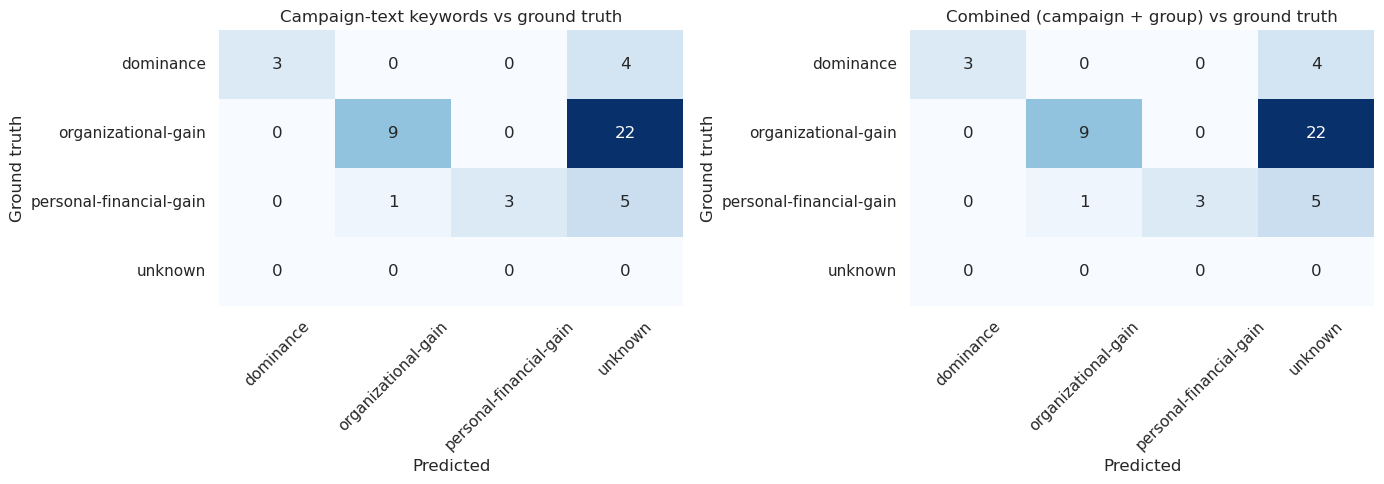


Disagreements (32):
campaign_id                                      campaign_name           gt_motivation       kw_motivation group_kw_motivation combined_motivation
      C0004                                         CostaRicto personal-financial-gain organizational-gain             unknown organizational-gain
      C0005                                   Operation Spalax     organizational-gain             unknown             unknown             unknown
      C0006                                 Operation Honeybee     organizational-gain             unknown             unknown             unknown
      C0017                                              C0017     organizational-gain             unknown             unknown             unknown
      C0018                                              C0018 personal-financial-gain             unknown             unknown             unknown
      C0021                                              C0021     organizational-gain           

In [29]:
# Cell 10 — Compare keyword extraction vs external ground truth

from sklearn.metrics import confusion_matrix, classification_report

# Merge keyword results with ground truth
eval_df = campaign_kw_df[["campaign_id", "campaign_name", "kw_motivation"]].copy()
eval_df["gt_motivation"] = eval_df["campaign_id"].map(GROUND_TRUTH).fillna("unknown")

# Also merge group-keyword results (take best group label per campaign)
group_best = (
    group_kw_df.sort_values("group_kw_confidence", ascending=False)
    .drop_duplicates("campaign_id", keep="first")
    [["campaign_id", "group_name", "group_kw_motivation", "group_kw_confidence"]]
)
eval_df = eval_df.merge(group_best, on="campaign_id", how="left")

# Combined decision: agreement -> confident; disagreement -> prefer group if group has signal
def combined_label(row):
    kw = row["kw_motivation"]
    gkw = row["group_kw_motivation"]
    if kw == gkw:
        return kw
    if gkw != "unknown" and kw == "unknown":
        return gkw
    if kw != "unknown" and gkw == "unknown":
        return kw
    # Disagreement with both having signal: prefer group text (richer CTI)
    return gkw if row["group_kw_confidence"] > 0 else kw

eval_df["combined_motivation"] = eval_df.apply(combined_label, axis=1)

# Filter to only campaigns with known ground truth for evaluation
known_mask = eval_df["gt_motivation"] != "unknown"
eval_known = eval_df[known_mask].copy()

print(f"Evaluating on {len(eval_known)} campaigns with known ground truth "
      f"({(~known_mask).sum()} excluded as 'unknown')\n")

# --- Campaign-text keyword extraction accuracy ---
all_labels = sorted(set(eval_known["gt_motivation"]) | set(eval_known["kw_motivation"]) - {"unknown"})
print("=== Campaign-text keyword extraction ===")
print(classification_report(eval_known["gt_motivation"], eval_known["kw_motivation"],
                            labels=all_labels, zero_division=0))

# --- Combined (campaign + group text) accuracy ---
print("=== Combined (campaign + group text) keyword extraction ===")
all_labels_comb = sorted(set(eval_known["gt_motivation"]) | set(eval_known["combined_motivation"]) - {"unknown"})
print(classification_report(eval_known["gt_motivation"], eval_known["combined_motivation"],
                            labels=all_labels_comb, zero_division=0))

# --- Confusion matrix heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred_col, title in [
    (axes[0], "kw_motivation", "Campaign-text keywords vs ground truth"),
    (axes[1], "combined_motivation", "Combined (campaign + group) vs ground truth"),
]:
    labels_for_cm = sorted(set(eval_known["gt_motivation"]) | set(eval_known[pred_col]))
    cm = confusion_matrix(eval_known["gt_motivation"], eval_known[pred_col], labels=labels_for_cm)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_for_cm,
                yticklabels=labels_for_cm, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Show disagreements
disagree = eval_known[eval_known["combined_motivation"] != eval_known["gt_motivation"]]
if len(disagree):
    print(f"\nDisagreements ({len(disagree)}):")
    print(disagree[["campaign_id", "campaign_name", "gt_motivation", "kw_motivation",
                     "group_kw_motivation", "combined_motivation"]].to_string(index=False))
else:
    print("\nNo disagreements.")

---
## Part 5 — Tactic distribution profiles *(stub)*

- **Cell 20**: Per-motivation normalised tactic distributions using the best-performing label source from Parts 2/3/4.
- **Cell 21**: Heatmap (motivation × tactic) + radar chart overlay.
- **Cell 22**: Export to `notebooks/gap_out/campaign_motivations_YYYY-MM-DD.csv` and `tactic_profiles_YYYY-MM-DD.json`. CSV: `campaign_id, name, motivation_label, label_source, confidence`.


In [22]:
# Cell 20 — stub (Part 5). Implement after Part 4.


In [23]:
# Cell 21 — stub (Part 5). Implement after Part 4.


In [24]:
# Cell 22 — stub (Part 5). Implement after Part 4.


---
## Part 6 — Summary and recommendations *(stub — Cell 23)*

To be written after Parts 1–5 complete. Five findings:
1. Whether the data gap is confirmed (Part 1).
2. Keyword extraction performance vs ground truth (Part 2).
3. Group-mediated inference reliability (Part 3).
4. Whether TTP clusters align with motivation (Part 4) — either direction is a valid thesis finding.
5. Recommendation for MTDShield: use tactic distribution profiles from Part 5 to parameterise adversary archetypes.


## Prompt

I am thinking the most defensible is that it is reasonable to assume that APT groups have 1 primary motivation. Thus, for campaigns, they are attributed to an APT group, thus using the APT group description, NLP can be used to deduce the primary motivation and populate primary motivation field using this. Maybe as further investigation, using external CTI referenced in MITRE and using that as input text into NLP model to map to primary motivation as defined by stix. (e.g. for all references in reference list in mitre group, run nlp model for motivation attribution)

Maybe another line of enquiry could be using the campaign descriptions themselves and running nlp model on them to map to stix motivations, and then campaign references in MITRE. Trying to stick with the MITRE framework for this one, because I reasonably trust the stuff they put up..

In terms of part 3 and 4 of the ATTACK motivation exploration notebook sections, they don't seem to be defensible lines of enquiry, so I have cut them. Part 2 with regex matching is a bit too rigid, and thus left many unknowns. Thus I think NLP is probably the right tool for this job .

Produce your plan to extend the current @notebooks/2026-04-16_MTDSim_ATTACKMotivationExploration.ipynb  notebook with further sections using NLP motivation extraction as above. I know you used a "ground truth" from external CTI, but your approach currently is a black box which I cannot understand or justify. Thus, adopt a grey-box approach, where I can understand what you have done and have the potential to manually verify against the datasets you are using (e.g. I can read a relatively easy motivation attribution from APT group description, see your result, and see your result is justified, e.g. the text says something along the lines of the specified motivation; if unclear, lay out the thought process). Your Claude NLP is reasonably good as a tool, consider that as the tool to be used, or another approaches. Justify, document, and be defensible. 

Stix uses this for primary motivation ###
Vocabulary Summary
accidental, coercion, dominance, ideology, notoriety, organizational-gain, personal-gain, personal-satisfaction, revenge, unpredictable
###